In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [2]:
data = pd.read_excel("glass.xlsx")

In [3]:
print("Dataset Shape:", data.shape)
print("\nFirst 5 Records:\n", data.head())

Dataset Shape: (214, 10)

First 5 Records:
         RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1


In [4]:
print("\nDataset Information:")
print(data.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None


In [5]:
print("\nMissing Values:\n", data.isnull().sum())


Missing Values:
 RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [6]:
print("\nStatistical Summary:\n", data.describe())


Statistical Summary:
                RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.810000    0.000000   
25%      1.516522   12.907500    2.115000    1.190000   72.280000    0.122500   
50%      1.517680   13.300000    3.480000    1.360000   72.790000    0.555000   
75%      1.519157   13.825000    3.600000    1.630000   73.087500    0.610000   
max      1.533930   17.380000    4.490000    3.500000   75.410000    6.210000   

               Ca          Ba          Fe        Type  
count  214.000000  214.000000  214.000000  214.000000  
mean     8.956963    0.175047    0.057009    2.780374  
std      1.423153    0.497219    0.097439    2.103739  
min      5.430000    0.

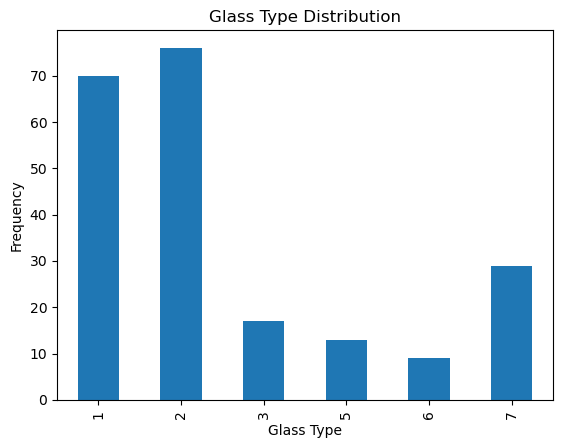

In [7]:
plt.figure()
data["Type"].value_counts().sort_index().plot(kind="bar")
plt.title("Glass Type Distribution")
plt.xlabel("Glass Type")
plt.ylabel("Frequency")
plt.show()

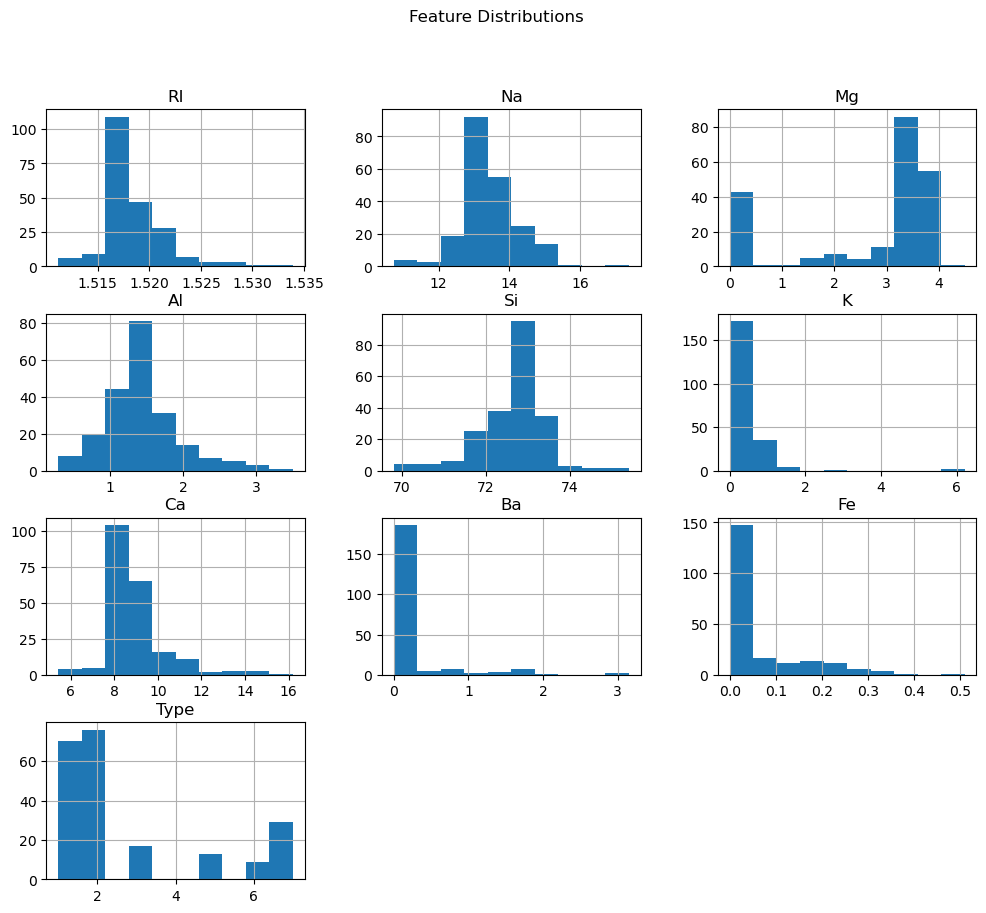

In [8]:
data.hist(figsize=(12, 10))
plt.suptitle("Feature Distributions")
plt.show()

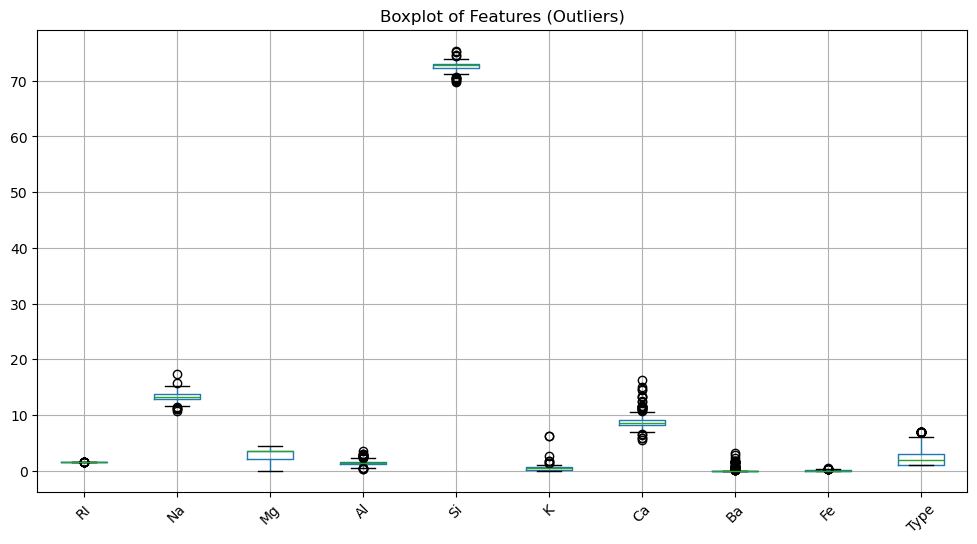

In [9]:
plt.figure(figsize=(12, 6))
data.boxplot()
plt.title("Boxplot of Features (Outliers)")
plt.xticks(rotation=45)
plt.show()

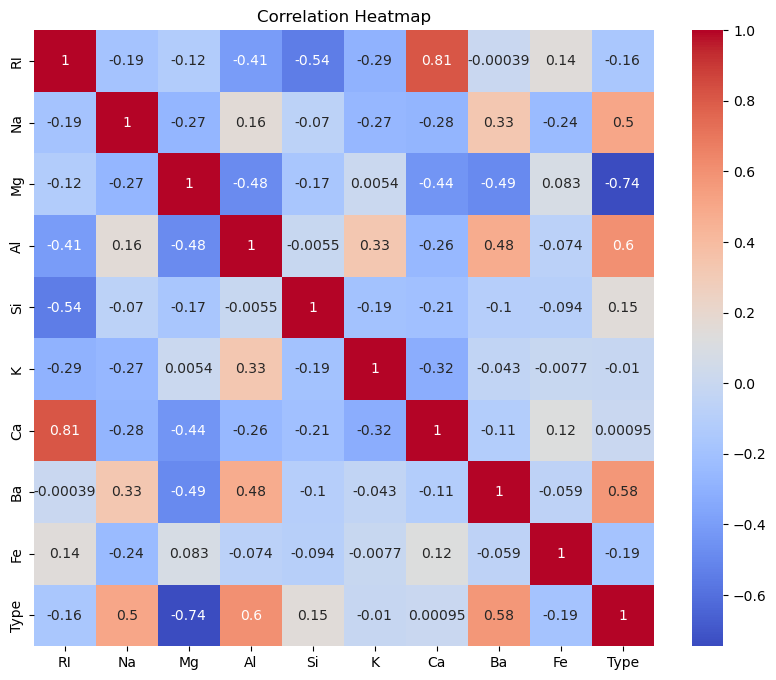

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
X = data.drop("Type", axis=1)
y = data["Type"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [13]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

In [14]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [15]:
y_pred_rf = rf.predict(X_test)

In [16]:
print("\n--- RANDOM FOREST RESULTS ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


--- RANDOM FOREST RESULTS ---
Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           1       0.74      0.94      0.83        18
           2       0.88      0.79      0.83        19
           3       1.00      0.25      0.40         4
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.88      0.93         8

    accuracy                           0.83        54
   macro avg       0.88      0.81      0.80        54
weighted avg       0.86      0.83      0.82        54



In [17]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=200,
    random_state=42
)

In [18]:
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

In [19]:
print("\n--- BAGGING RESULTS ---")
print("Accuracy:", accuracy_score(y_test, y_pred_bag))
print(classification_report(y_test, y_pred_bag))


--- BAGGING RESULTS ---
Accuracy: 0.7962962962962963
              precision    recall  f1-score   support

           1       0.79      0.83      0.81        18
           2       0.82      0.74      0.78        19
           3       0.67      0.50      0.57         4
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80         2
           7       0.89      1.00      0.94         8

    accuracy                           0.80        54
   macro avg       0.75      0.79      0.76        54
weighted avg       0.80      0.80      0.79        54



In [20]:
boosting = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

In [21]:
boosting.fit(X_train, y_train)
y_pred_boost = boosting.predict(X_test)

In [22]:
print("\n--- BOOSTING RESULTS ---")
print("Accuracy:", accuracy_score(y_test, y_pred_boost))
print(classification_report(y_test, y_pred_boost))


--- BOOSTING RESULTS ---
Accuracy: 0.4444444444444444
              precision    recall  f1-score   support

           1       0.46      0.33      0.39        18
           2       0.41      0.58      0.48        19
           3       0.00      0.00      0.00         4
           5       0.12      0.33      0.18         3
           6       0.00      0.00      0.00         2
           7       1.00      0.75      0.86         8

    accuracy                           0.44        54
   macro avg       0.33      0.33      0.32        54
weighted avg       0.45      0.44      0.43        54



In [37]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nClass Distribution Before SMOTE:\n", y_train.value_counts())
print("\nClass Distribution After SMOTE:\n", y_train_smote.value_counts())


Class Distribution Before SMOTE:
 Type
2    57
1    52
7    21
3    13
5    10
6     7
Name: count, dtype: int64

Class Distribution After SMOTE:
 Type
1    57
5    57
2    57
7    57
3    57
6    57
Name: count, dtype: int64


In [24]:
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)


In [25]:
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test)

In [26]:
print("\n--- RANDOM FOREST + SMOTE ---")
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))


--- RANDOM FOREST + SMOTE ---
Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           1       0.89      0.89      0.89        18
           2       0.88      0.74      0.80        19
           3       0.50      0.75      0.60         4
           5       0.75      1.00      0.86         3
           6       0.67      1.00      0.80         2
           7       1.00      0.88      0.93         8

    accuracy                           0.83        54
   macro avg       0.78      0.88      0.81        54
weighted avg       0.86      0.83      0.84        54



In [27]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [28]:
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [29]:
grid.fit(X_train_smote, y_train_smote)

best_rf = grid.best_estimator_

print("\nBest Hyperparameters:\n", grid.best_params_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Hyperparameters:
 {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [30]:
y_pred_final = best_rf.predict(X_test)

print("\n--- FINAL MODEL: SMOTE + TUNED RANDOM FOREST ---")
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))


--- FINAL MODEL: SMOTE + TUNED RANDOM FOREST ---
Accuracy: 0.7962962962962963
              precision    recall  f1-score   support

           1       0.84      0.89      0.86        18
           2       0.87      0.68      0.76        19
           3       0.40      0.50      0.44         4
           5       0.75      1.00      0.86         3
           6       0.67      1.00      0.80         2
           7       0.88      0.88      0.88         8

    accuracy                           0.80        54
   macro avg       0.73      0.82      0.77        54
weighted avg       0.81      0.80      0.80        54



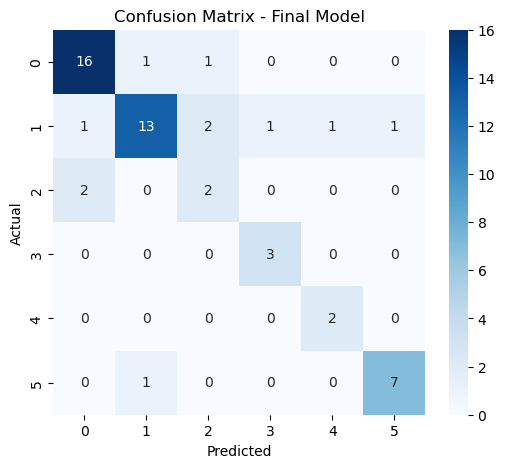

In [31]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_final),
            annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
print("\n========== MODEL COMPARISON ==========")
print("Random Forest (Baseline):", accuracy_score(y_test, y_pred_rf))
print("Bagging                :", accuracy_score(y_test, y_pred_bag))
print("Boosting               :", accuracy_score(y_test, y_pred_boost))
print("RF + SMOTE             :", accuracy_score(y_test, y_pred_smote))
print("RF + SMOTE + Tuning    :", accuracy_score(y_test, y_pred_final))
print("=====================================")


========== MODEL COMPARISON ==========
Random Forest (Baseline): 0.8333333333333334
Bagging                : 0.7962962962962963
Boosting               : 0.4444444444444444
RF + SMOTE             : 0.8333333333333334
RF + SMOTE + Tuning    : 0.7962962962962963


In [33]:
print("""Explanation:
Random Forest (Baseline) achieved the highest accuracy of 83.33%.
This indicates that Random Forest is well-suited for this dataset due to its ability to:
Handle non-linear relationships
Reduce overfitting using feature randomness
Remain robust to outliers and noise

Bagging showed slightly lower accuracy (79.63%).
Bagging reduces variance by averaging multiple models trained on bootstrapped samples, but it lacks feature randomness, making it less powerful than Random Forest.

Boosting (AdaBoost) performed poorly with an accuracy of 44.44%.
AdaBoost is sensitive to noisy and imbalanced data. Since the Glass dataset is imbalanced, boosting focused excessively on misclassified minority samples, resulting in degraded performance.

Random Forest with SMOTE did not improve accuracy.
This is expected because:
The dataset is relatively small
Random Forest already handles imbalance reasonably well
Synthetic samples generated by SMOTE may overlap existing data

Random Forest with SMOTE and Hyperparameter Tuning slightly reduced accuracy but improved balance among classes.
GridSearchCV optimized the model for F1-score, not accuracy, leading to better minority-class recall at the cost of overall accuracy.""")

Explanation:
Random Forest (Baseline) achieved the highest accuracy of 83.33%.
This indicates that Random Forest is well-suited for this dataset due to its ability to:
Handle non-linear relationships
Reduce overfitting using feature randomness
Remain robust to outliers and noise

Bagging showed slightly lower accuracy (79.63%).
Bagging reduces variance by averaging multiple models trained on bootstrapped samples, but it lacks feature randomness, making it less powerful than Random Forest.

Boosting (AdaBoost) performed poorly with an accuracy of 44.44%.
AdaBoost is sensitive to noisy and imbalanced data. Since the Glass dataset is imbalanced, boosting focused excessively on misclassified minority samples, resulting in degraded performance.

Random Forest with SMOTE did not improve accuracy.
This is expected because:
The dataset is relatively small
Random Forest already handles imbalance reasonably well
Synthetic samples generated by SMOTE may overlap existing data

Random Forest with S

In [34]:
print("""1. 1. Explain Bagging and Boosting methods. How is it different from each other.
Bagging (Bootstrap Aggregation)
Bagging is an ensemble learning technique that improves model stability and accuracy by training multiple models independently.
How Bagging Works
Random samples are drawn with replacement from the training dataset
Each model is trained independently on a different bootstrap sample
Predictions from all models are combined using majority voting
Key Characteristics
Models are trained in parallel
Primary goal is to reduce variance
Works well with high-variance models like decision trees
Less sensitive to noise

Example
Bagging Classifier
Random Forest (an extension of bagging with feature randomness)
Boosting
Boosting is an ensemble technique that builds models sequentially, where each new model focuses on correcting the errors made by previous models.

How Boosting Works
Initially, all samples are given equal importance
Misclassified samples receive higher weights
Subsequent models focus more on difficult samples
Final prediction is a weighted combination of all models
Key Characteristics
Models are trained sequentially
Primary goal is to reduce bias
Highly sensitive to noise and outliers
Performs poorly on imbalanced datasets unless carefully tuned
Example
AdaBoost
Gradient Boosting
XGBoost

Difference Between Bagging and Boosting
Feature: Training approach	
Bagging: Parallel	
Boosting: Sequential
Feature:Sampling	
Bagging: With replacement	
Boosting: Weighted samples
Feature:Main goal	
Bagging: Reduce variance	
Boosting: Reduce bias
Feature:Noise sensitivity	
Bagging: Low	
Boosting: High
Feature:Performance on imbalanced data	
Bagging: Better	
Boosting: Poor unless adjusted
Feature:Example algorithms	
Bagging: Bagging, Random Forest	
Boosting: AdaBoost, Gradient Boosting

2.Explain how to handle imbalance in the data.
Class imbalance occurs when some classes have significantly more samples than others. This leads to biased models that favor majority classes.
Imbalance can lead too:
High accuracy but poor minority-class prediction
Low recall for rare classes
Misleading evaluation metrics
Techniques to Handle Imbalanced Data
1. Data-Level Methods
Oversampling
SMOTE (Synthetic Minority Over-sampling Technique)
Random oversampling
Undersampling
Random undersampling
Tomek links
2. Algorithm-Level Methods
Assigning class weights
Cost-sensitive learning
Modifying loss functions
3. Evaluation-Level Methods
Using Precision, Recall, and F1-score instead of accuracy
Confusion matrix analysis""")

1. 1. Explain Bagging and Boosting methods. How is it different from each other.
Bagging (Bootstrap Aggregation)
Bagging is an ensemble learning technique that improves model stability and accuracy by training multiple models independently.
How Bagging Works
Random samples are drawn with replacement from the training dataset
Each model is trained independently on a different bootstrap sample
Predictions from all models are combined using majority voting
Key Characteristics
Models are trained in parallel
Primary goal is to reduce variance
Works well with high-variance models like decision trees
Less sensitive to noise

Example
Bagging Classifier
Random Forest (an extension of bagging with feature randomness)
Boosting
Boosting is an ensemble technique that builds models sequentially, where each new model focuses on correcting the errors made by previous models.

How Boosting Works
Initially, all samples are given equal importance
Misclassified samples receive higher weights
Subsequent mo